# Recommendation Systems

This notebook covers collaborative filtering, content-based,
and hybrid recommendation approaches with hands-on implementations.

**Prerequisites:**
```bash
pip install numpy matplotlib scikit-learn pandas
```

📺 **Video Lecture:** [https://youtu.be/8-Y8X7ZOD2s](https://youtu.be/8-Y8X7ZOD2s)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
np.random.seed(42)

print('Libraries loaded!')

Libraries loaded!


## 1. User-Item Rating Matrix

The foundation of recommendation systems: who rated what and how.

In [3]:
# Create a synthetic movie rating matrix
users = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank', 'Grace', 'Hank']
movies = ['Inception', 'Titanic', 'Matrix', 'Notebook', 'Avengers',
          'Pride & Prejudice', 'Interstellar', 'Mean Girls']

# Rating matrix (0 = not rated)
ratings = np.array([
    [5, 3, 5, 1, 4, 1, 5, 2],  # Alice likes sci-fi/action
    [4, 2, 4, 0, 5, 0, 4, 1],  # Bob similar to Alice
    [1, 5, 2, 5, 1, 5, 2, 4],  # Carol likes romance/drama
    [2, 4, 1, 4, 0, 4, 1, 5],  # Dave similar to Carol
    [5, 0, 4, 2, 5, 0, 5, 0],  # Eve likes action/sci-fi
    [0, 4, 0, 5, 2, 5, 0, 4],  # Frank likes romance
    [4, 3, 5, 2, 4, 2, 4, 3],  # Grace mixed
    [3, 0, 3, 0, 4, 0, 3, 0],  # Hank sparse ratings
], dtype=float)

df_ratings = pd.DataFrame(ratings, index=users, columns=movies)
print('User-Item Rating Matrix:')
print(df_ratings.replace(0, '-'))
print(f'\nSparsity: {(ratings == 0).sum() / ratings.size * 100:.1f}% (typical real-world: 95-99%)')

User-Item Rating Matrix:
      Inception Titanic Matrix Notebook Avengers Pride & Prejudice  \
Alice       5.0     3.0    5.0      1.0      4.0               1.0   
Bob         4.0     2.0    4.0        -      5.0                 -   
Carol       1.0     5.0    2.0      5.0      1.0               5.0   
Dave        2.0     4.0    1.0      4.0        -               4.0   
Eve         5.0       -    4.0      2.0      5.0                 -   
Frank         -     4.0      -      5.0      2.0               5.0   
Grace       4.0     3.0    5.0      2.0      4.0               2.0   
Hank        3.0       -    3.0        -      4.0                 -   

      Interstellar Mean Girls  
Alice          5.0        2.0  
Bob            4.0        1.0  
Carol          2.0        4.0  
Dave           1.0        5.0  
Eve            5.0          -  
Frank            -        4.0  
Grace          4.0        3.0  
Hank           3.0          -  

Sparsity: 20.3% (typical real-world: 95-99%)


## 2. User-Based Collaborative Filtering

**Key idea**: Users who agreed in the past will agree in the future.
Find similar users, then recommend what they liked.

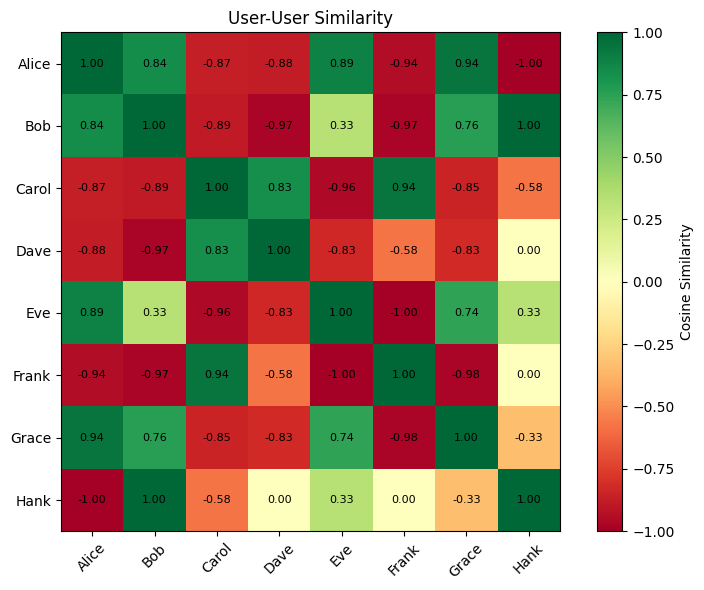

Note: Alice-Bob are similar (both like sci-fi); Carol-Dave are similar (both like romance)


In [4]:
# Compute user-user similarity (using rated items only)
def user_similarity(ratings):
    """Cosine similarity between users, considering only co-rated items."""
    n_users = ratings.shape[0]
    sim = np.zeros((n_users, n_users))
    for i in range(n_users):
        for j in range(n_users):
            # Only consider items both users rated
            mask = (ratings[i] > 0) & (ratings[j] > 0)
            if mask.sum() > 0:
                r_i = ratings[i, mask]
                r_j = ratings[j, mask]
                # Center ratings (mean-adjusted)
                r_i_centered = r_i - r_i.mean()
                r_j_centered = r_j - r_j.mean()
                denom = np.linalg.norm(r_i_centered) * np.linalg.norm(r_j_centered)
                sim[i, j] = np.dot(r_i_centered, r_j_centered) / denom if denom > 0 else 0
    return sim

sim_matrix = user_similarity(ratings)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(users))); ax.set_xticklabels(users, rotation=45)
ax.set_yticks(range(len(users))); ax.set_yticklabels(users)
for i in range(len(users)):
    for j in range(len(users)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Cosine Similarity')
ax.set_title('User-User Similarity'); plt.tight_layout(); plt.show()
print('Note: Alice-Bob are similar (both like sci-fi); Carol-Dave are similar (both like romance)')

## 3. Predict Missing Ratings

In [5]:
def predict_rating(user_idx, item_idx, ratings, sim_matrix, k=3):
    """
    Predict a user's rating for an unrated item using k nearest neighbors.
    weighted_avg = sum(sim * rating) / sum(|sim|)
    """
    # Find users who rated this item
    rated_mask = ratings[:, item_idx] > 0
    rated_mask[user_idx] = False  # exclude the user themselves
    
    if not rated_mask.any():
        return ratings[user_idx][ratings[user_idx] > 0].mean()  # fallback to user mean
    
    # Get similarities and ratings of those users
    sims = sim_matrix[user_idx, rated_mask]
    item_ratings = ratings[rated_mask, item_idx]
    
    # Top-k most similar
    if len(sims) > k:
        top_k_idx = np.argsort(np.abs(sims))[-k:]
        sims = sims[top_k_idx]
        item_ratings = item_ratings[top_k_idx]
    
    # Weighted average
    denom = np.abs(sims).sum()
    if denom == 0:
        return ratings[user_idx][ratings[user_idx] > 0].mean()
    return np.dot(sims, item_ratings) / denom

# Predict missing ratings for Alice (user 0)
alice_idx = 0
print('Predictions for Alice (actual | predicted):')
for j, movie in enumerate(movies):
    actual = ratings[alice_idx, j]
    predicted = predict_rating(alice_idx, j, ratings, sim_matrix)
    status = f'actual={actual:.0f}' if actual > 0 else 'NOT RATED'
    print(f'  {movie:20s}: pred={predicted:.2f}  ({status})')

Predictions for Alice (actual | predicted):
  Inception           : pred=1.84  (actual=5)
  Titanic             : pred=-1.61  (actual=3)
  Matrix              : pred=1.86  (actual=5)
  Notebook            : pred=-0.38  (actual=1)
  Avengers            : pred=-0.73  (actual=4)
  Pride & Prejudice   : pred=-2.29  (actual=1)
  Interstellar        : pred=1.84  (actual=5)
  Mean Girls          : pred=-1.93  (actual=2)


## 4. Item-Based Collaborative Filtering

Instead of similar users, find similar items. Often more stable
because item similarities change less than user preferences.

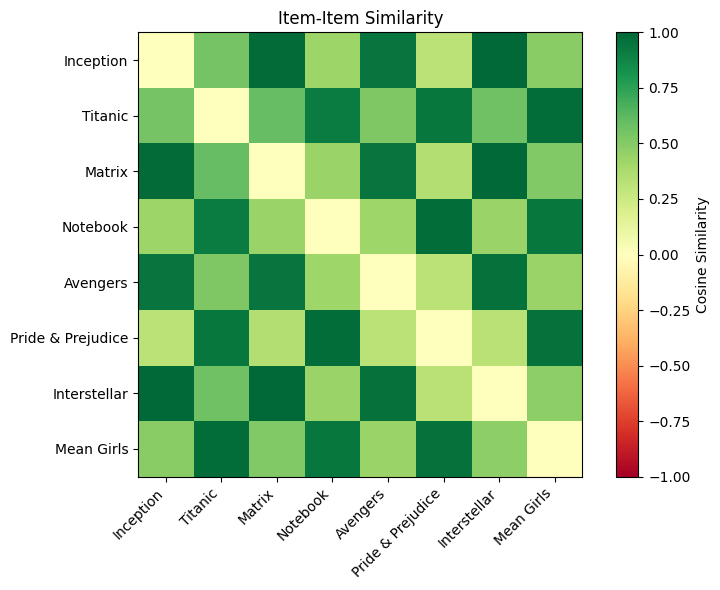

Inception            -> most similar: Interstellar         (sim=0.990)
Titanic              -> most similar: Mean Girls           (sim=0.975)
Matrix               -> most similar: Interstellar         (sim=0.990)
Notebook             -> most similar: Pride & Prejudice    (sim=0.973)
Avengers             -> most similar: Interstellar         (sim=0.955)
Pride & Prejudice    -> most similar: Notebook             (sim=0.973)
Interstellar         -> most similar: Inception            (sim=0.990)
Mean Girls           -> most similar: Titanic              (sim=0.975)


In [6]:
# Item-item similarity
item_sim = cosine_similarity(ratings.T)
np.fill_diagonal(item_sim, 0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(item_sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(movies))); ax.set_xticklabels(movies, rotation=45, ha='right')
ax.set_yticks(range(len(movies))); ax.set_yticklabels(movies)
plt.colorbar(im, label='Cosine Similarity')
ax.set_title('Item-Item Similarity'); plt.tight_layout(); plt.show()

# Find most similar movies
for i, movie in enumerate(movies):
    most_similar_idx = np.argmax(item_sim[i])
    print(f'{movie:20s} -> most similar: {movies[most_similar_idx]:20s} (sim={item_sim[i, most_similar_idx]:.3f})')

## 5. Matrix Factorization (SVD)

Decompose the rating matrix into latent factors: R = U x S x V^T.
Captures hidden patterns (e.g., user preference for genres).

Original vs Reconstructed ratings (Alice):
  Inception           : original=5  reconstructed=4.94
  Titanic             : original=3  reconstructed=2.61
  Matrix              : original=5  reconstructed=5.15
  Notebook            : original=1  reconstructed=0.98
  Avengers            : original=4  reconstructed=3.96
  Pride & Prejudice   : original=1  reconstructed=1.09
  Interstellar        : original=5  reconstructed=5.01
  Mean Girls          : original=2  reconstructed=2.27

* = was not rated (prediction from latent factors)


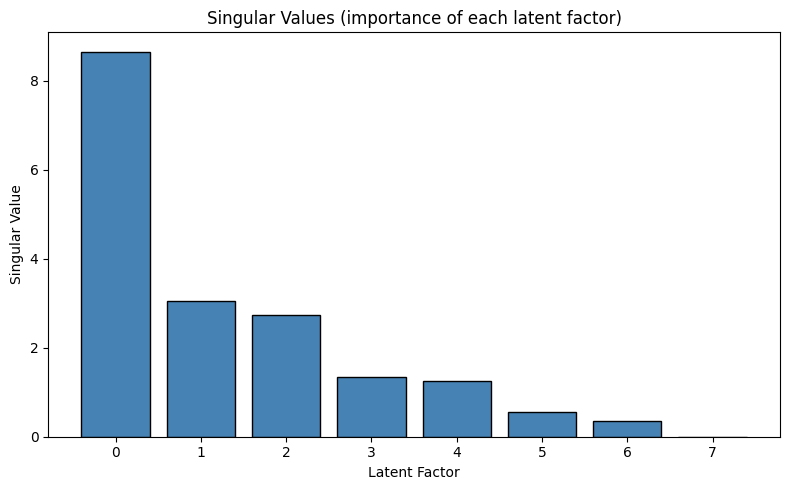

In [7]:
# Fill missing values with item means for SVD
ratings_filled = ratings.copy()
for j in range(ratings.shape[1]):
    col = ratings[:, j]
    mean_val = col[col > 0].mean() if (col > 0).any() else 3.0
    ratings_filled[col == 0, j] = mean_val

# Center the matrix
user_means = ratings_filled.mean(axis=1, keepdims=True)
R_centered = ratings_filled - user_means

# SVD decomposition
U, S, Vt = np.linalg.svd(R_centered, full_matrices=False)

# Keep top-k latent factors
k = 3
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

# Reconstruct ratings
R_reconstructed = U_k @ S_k @ Vt_k + user_means

print('Original vs Reconstructed ratings (Alice):')
for j, movie in enumerate(movies):
    orig = ratings[0, j]
    recon = R_reconstructed[0, j]
    flag = ' *' if orig == 0 else ''
    print(f'  {movie:20s}: original={orig:.0f}  reconstructed={recon:.2f}{flag}')
print('\n* = was not rated (prediction from latent factors)')

# Visualize latent factors
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(S)), S, color='steelblue', edgecolor='black')
ax.set_xlabel('Latent Factor'); ax.set_ylabel('Singular Value')
ax.set_title('Singular Values (importance of each latent factor)')
plt.tight_layout(); plt.show()

## 6. Content-Based Filtering

Recommend items similar to what the user already liked,
based on item features (genres, descriptions, etc.).

In [8]:
# Movie features: [action, romance, sci-fi, drama, comedy]
movie_features = np.array([
    [0.8, 0.1, 0.9, 0.3, 0.1],  # Inception
    [0.1, 0.9, 0.0, 0.8, 0.1],  # Titanic
    [0.9, 0.0, 1.0, 0.2, 0.0],  # Matrix
    [0.0, 1.0, 0.0, 0.7, 0.3],  # Notebook
    [1.0, 0.1, 0.5, 0.2, 0.3],  # Avengers
    [0.0, 0.9, 0.0, 0.8, 0.2],  # Pride & Prejudice
    [0.6, 0.2, 1.0, 0.5, 0.0],  # Interstellar
    [0.0, 0.4, 0.0, 0.3, 0.9],  # Mean Girls
])

def content_based_recommend(user_ratings, movie_features, n=3):
    """
    Build user profile from rated movies, then find similar unrated movies.
    """
    rated_mask = user_ratings > 0
    
    # User profile = weighted average of rated movie features
    weights = user_ratings[rated_mask]
    weighted_features = movie_features[rated_mask] * weights[:, np.newaxis]
    user_profile = weighted_features.sum(axis=0) / weights.sum()
    
    # Score unrated movies by similarity to profile
    scores = cosine_similarity(user_profile.reshape(1, -1), movie_features)[0]
    scores[rated_mask] = -1  # exclude already rated
    
    top_n = np.argsort(scores)[-n:][::-1]
    return top_n, scores[top_n], user_profile

# Recommend for Alice
top_movies, scores, profile = content_based_recommend(ratings[0], movie_features)
genre_names = ['Action', 'Romance', 'Sci-Fi', 'Drama', 'Comedy']

print(f'Alice\'s taste profile: {dict(zip(genre_names, np.round(profile, 2)))}')
print(f'\nTop recommendations:')
for idx, score in zip(top_movies, scores):
    print(f'  {movies[idx]:20s} (similarity: {score:.3f})')

Alice's taste profile: {'Action': np.float64(0.61), 'Romance': np.float64(0.28), 'Sci-Fi': np.float64(0.63), 'Drama': np.float64(0.4), 'Comedy': np.float64(0.17)}

Top recommendations:
  Mean Girls           (similarity: -1.000)
  Interstellar         (similarity: -1.000)
  Pride & Prejudice    (similarity: -1.000)


## 7. Evaluation Metrics

In [9]:
def evaluate_recommendations(predictions, actuals, k=5):
    """Evaluate recommendation quality."""
    # Precision@K: fraction of recommended items that are relevant
    recommended = np.argsort(predictions)[-k:][::-1]
    relevant = set(np.where(actuals >= 4)[0])  # items rated 4+
    
    hits = len(set(recommended) & relevant)
    precision_k = hits / k
    recall_k = hits / len(relevant) if len(relevant) > 0 else 0
    
    # NDCG@K
    dcg = sum(actuals[recommended[i]] / np.log2(i + 2) for i in range(k))
    ideal_order = np.sort(actuals)[::-1][:k]
    idcg = sum(ideal_order[i] / np.log2(i + 2) for i in range(k))
    ndcg = dcg / idcg if idcg > 0 else 0
    
    return {'Precision@K': precision_k, 'Recall@K': recall_k, 'NDCG@K': ndcg}

# Evaluate Alice's recommendations from SVD
alice_preds = R_reconstructed[0]
alice_actual = ratings_filled[0]
metrics = evaluate_recommendations(alice_preds, alice_actual, k=3)

print('Evaluation Metrics for Alice (K=3):')
for metric, value in metrics.items():
    print(f'  {metric}: {value:.3f}')

Evaluation Metrics for Alice (K=3):
  Precision@K: 1.000
  Recall@K: 0.750
  NDCG@K: 1.000


## 8. Interview Takeaways

**Key concepts:**

- **Collaborative filtering**: user-based (find similar users) vs item-based (find similar items)
- **Content-based**: recommend based on item features the user likes
- **Matrix factorization** (SVD, ALS): discover latent factors (genres, preferences)
- **Cold start problem**: new users/items have no history (use content-based or hybrid)
- **Sparsity**: real rating matrices are 95-99% empty
- **Evaluation**: Precision@K, Recall@K, NDCG, MAP, Hit Rate
- **Modern approaches**: deep learning (NCF, autoencoders), two-tower models, transformers
- **Production**: candidate generation (fast, broad) + ranking (precise, expensive)

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>